# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SupreetOP/Flyrank/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

### Research question

Can observed content-performance signals from the previous month be used to identify which content items are more likely to receive Google Search Console clicks in the following month, and can a learned model provide useful decision-support beyond a simple rule-based baseline?

### Decision supported

The output is intended to help content teams prioritize content items for human review. Higher-priority items can be investigated first for possible content refresh opportunities, while lower-priority items can be monitored.

The model does not determine that a page should be refreshed. It provides directional decision-support that should be reviewed alongside search intent, content quality, seasonality, technical factors, and business context.

### Unit of analysis

The unit of analysis is a client-content item pair for a monthly observation window.

### Why data and ML help

A simple rule can identify obvious patterns such as high search visibility combined with low CTR. A machine-learning model can combine several historical search and analytics signals and learn relationships that a fixed rule may not capture.

The model is therefore evaluated against the transparent Week-4 rule-based baseline rather than being judged on its performance alone.

In [14]:
# ============================================================
# SECTION 1 — QUESTION / TASK SUMMARY
# ============================================================

task_summary = {
    "unit_of_analysis": "client-content item pair per monthly observation window",
    "feature_window": "March 2026",
    "outcome_window": "April 2026",
    "target": "future_gsc_clicks > 0",
    "model": "Random Forest",
    "decision_support": "prioritize content items for human review"
}

print("=" * 70)
print("CAPSTONE — RESEARCH QUESTION")
print("=" * 70)

for key, value in task_summary.items():
    print(f"{key}: {value}")

CAPSTONE — RESEARCH QUESTION
unit_of_analysis: client-content item pair per monthly observation window
feature_window: March 2026
outcome_window: April 2026
target: future_gsc_clicks > 0
model: Random Forest
decision_support: prioritize content items for human review


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [15]:
!pip -q install duckdb

import duckdb
import pandas as pd
from google.colab import userdata

print("DuckDB and pandas ready.")

DuckDB and pandas ready.


In [16]:
HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError("HF_TOKEN was not found in Colab Secrets.")

con = duckdb.connect()

con.execute(f"""
    CREATE OR REPLACE SECRET hf_secret
    (TYPE huggingface, TOKEN '{HF_TOKEN}')
""")

print("Hugging Face authentication configured.")

Hugging Face authentication configured.


In [17]:

# SECTION 2 — DATASET / DATE RANGE CHECK


DATA_PATH = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/**/*.parquet"
)

date_check = con.sql(f"""
    SELECT
        MIN(report_date) AS min_date,
        MAX(report_date) AS max_date,
        COUNT(*) AS total_rows
    FROM read_parquet('{DATA_PATH}')
""").df()

print("=" * 70)
print("FLYRANK DATASET CHECK")
print("=" * 70)

display(date_check)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FLYRANK DATASET CHECK


,min_date,max_date,total_rows
0,2025-01-27,2026-06-30,78835655


In [18]:

# SECTION 2 — FEATURE / COLUMN CHECK


schema_check = con.sql(f"""
    DESCRIBE
    SELECT *
    FROM read_parquet('{DATA_PATH}')
    LIMIT 1
""").df()

print("=" * 70)
print("DATASET COLUMNS")
print("=" * 70)

display(schema_check[["column_name", "column_type"]])

DATASET COLUMNS


,column_name,column_type
0,report_date,DATE
1,client_hash_id,VARCHAR
2,content_hash_id,VARCHAR
3,client_has_gsc,BOOLEAN
4,client_has_ga4,BOOLEAN
5,gsc_data_available,BOOLEAN
6,ga4_data_available,BOOLEAN
7,gsc_impressions,BIGINT
8,gsc_clicks,BIGINT
9,gsc_sum_position,BIGINT


In [19]:

# SECTION 2 — FINAL DATA CONTRACT


MODEL_FEATURES = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_engaged_sessions"
]

EXCLUDED_COLUMNS = [
    "client_hash_id",
    "content_hash_id",
    "client_has_gsc",
    "client_has_ga4",
    "gsc_data_available",
    "ga4_data_available",
    "gsc_sum_position",
    "ga4_sessions",
    "ga4_users",
    "ga4_total_engagement_sec",
    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid",
    "sessions_ai",
    "ai_chatgpt",
    "ai_perplexity",
    "ai_gemini",
    "ai_copilot",
    "ai_claude",
    "ai_meta",
    "ai_other",
    "scroll_events",
    "report_date",
    "month"
]

print("=" * 70)
print("FINAL DATA CONTRACT")
print("=" * 70)

print("\nDataset:")
print("FlyRank internship warehouse — fact_content_daily_performance")

print("\nObserved data range:")
print("2025-01-27 to 2026-06-30")

print("\nTotal warehouse rows:")
print(f"{date_check['total_rows'].iloc[0]:,}")

print("\nFeature window:")
print("March 2026")

print("\nOutcome window:")
print("April 2026")

print("\nMODEL FEATURES")
print("-" * 70)
for feature in MODEL_FEATURES:
    print("-", feature)

print("\nEXCLUDED FROM MODEL")
print("-" * 70)
for column in EXCLUDED_COLUMNS:
    print("-", column)

FINAL DATA CONTRACT

Dataset:
FlyRank internship warehouse — fact_content_daily_performance

Observed data range:
2025-01-27 to 2026-06-30

Total warehouse rows:
78,835,655

Feature window:
March 2026

Outcome window:
April 2026

MODEL FEATURES
----------------------------------------------------------------------
- gsc_impressions
- gsc_clicks
- gsc_avg_position
- ga4_pageviews
- ga4_engaged_sessions

EXCLUDED FROM MODEL
----------------------------------------------------------------------
- client_hash_id
- content_hash_id
- client_has_gsc
- client_has_ga4
- gsc_data_available
- ga4_data_available
- gsc_sum_position
- ga4_sessions
- ga4_users
- ga4_total_engagement_sec
- sessions_organic
- sessions_direct
- sessions_referral
- sessions_social
- sessions_paid
- sessions_ai
- ai_chatgpt
- ai_perplexity
- ai_gemini
- ai_copilot
- ai_claude
- ai_meta
- ai_other
- scroll_events
- report_date
- month


### Data used and exclusions

The analysis uses the `fact_content_daily_performance` table from the FlyRank internship warehouse. The observed warehouse data spans 2025-01-27 through 2026-06-30 and contains 78,835,655 rows.

For the final modeling workflow, March 2026 is used as the decision-time feature window and April 2026 as the future outcome window.

The final feature set contains five observed performance signals: GSC impressions, GSC clicks, GSC average position, GA4 pageviews, and GA4 engaged sessions.

Pseudonymous client and content identifiers are used only to join and group observations and are not used as model features. Other fields, including availability flags, unused traffic-channel measures, future-window measurements, and target-derived fields, were excluded from the model to avoid unnecessary shortcut or leakage risks.

No client names, private search queries, or other client-identifying information are included in the analysis output.

## 3. Methodology

### Approach

The analysis uses a Random Forest classifier to estimate whether a content item will have at least one Google Search Console click in the following month.

### Features

The model uses five features available at the decision moment:

- `gsc_impressions`
- `gsc_clicks`
- `gsc_avg_position`
- `ga4_pageviews`
- `ga4_engaged_sessions`

These features describe observed content performance during March 2026. Client and content identifiers are not used as predictive features.

### Target definition

The binary target is defined as:

`future_gsc_clicks > 0`

where `future_gsc_clicks` represents Google Search Console clicks observed during April 2026.

### Baseline

The Week-4 baseline is a transparent rule-based score. It identifies content with at least 100 impressions and CTR below 2% as a refresh opportunity. Items that do not meet both conditions receive a `MONITOR` action.

The baseline provides a simple and interpretable comparison for evaluating whether the learned model adds measured predictive value.

### Validation design

The primary evaluation uses a time-aware split. March 2026 observations provide the decision-time features and April 2026 observations provide the future outcome. The resulting modeling dataset contains 331,436 matched content items.

The data is divided into training and validation sets while preserving the target proportion. The validation results are used to compare the Random Forest with the Week-4 baseline on the same held-out observations.

### Leakage controls

The final feature set was checked for obvious future-window, target-derived, product-flag, and label-derived fields. The future target `future_gsc_clicks` is not included in the feature matrix.

Pseudonymous client and content identifiers are used for joining and grouping but are not supplied to the model as predictive features.

### Interpretation principle

The model is treated as decision-support. Higher predictive performance on the validation data does not establish that changing a page will cause more clicks, and the model does not establish the reason why a content item performs as it does.

In [20]:

# SECTION 3 — METHODOLOGY CHECK


MODEL_FEATURES = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_engaged_sessions"
]

TARGET = "future_gsc_clicks"

BASELINE_MIN_IMPRESSIONS = 100
BASELINE_MAX_CTR = 0.02

print("=" * 70)
print("METHODOLOGY SUMMARY")
print("=" * 70)

print("\nMODEL")
print("Random Forest classifier")

print("\nFEATURES")
for feature in MODEL_FEATURES:
    print("-", feature)

print("\nTARGET")
print(f"{TARGET} > 0")

print("\nBASELINE RULE")
print(f"Impressions >= {BASELINE_MIN_IMPRESSIONS}")
print(f"CTR < {BASELINE_MAX_CTR:.2%}")

print("\nTIME-AWARE WINDOWS")
print("Feature window: March 2026")
print("Outcome window: April 2026")

print("\nVALIDATION DESIGN")
print("Held-out validation data with preserved target proportion")

print("\nLEAKAGE CONTROL")
print("Future target excluded from model features")
print("Client/content identifiers excluded from model features")

METHODOLOGY SUMMARY

MODEL
Random Forest classifier

FEATURES
- gsc_impressions
- gsc_clicks
- gsc_avg_position
- ga4_pageviews
- ga4_engaged_sessions

TARGET
future_gsc_clicks > 0

BASELINE RULE
Impressions >= 100
CTR < 2.00%

TIME-AWARE WINDOWS
Feature window: March 2026
Outcome window: April 2026

VALIDATION DESIGN
Held-out validation data with preserved target proportion

LEAKAGE CONTROL
Future target excluded from model features
Client/content identifiers excluded from model features


## 4. Results (vs baseline)

The Random Forest was evaluated against the Week-4 rule-based baseline on the same held-out validation data and using the same metrics.

The measured results show higher discrimination for the Random Forest on this validation split. ROC-AUC increased from 0.8447 for the baseline to 0.9312 for the Random Forest, while PR-AUC increased from 0.4858 to 0.8397. Accuracy increased from 0.8325 to 0.8762.

These results show that the learned model performed better than the simple baseline on the evaluated validation data. They should be interpreted as measured predictive performance on this split, not as evidence that the model causes improved content performance or that every high-scoring item should be refreshed.

In [21]:

# SECTION 4 — MODEL VS BASELINE


results = pd.DataFrame({
    "Method": [
        "Week-4 Rule Baseline",
        "Random Forest"
    ],
    "ROC-AUC": [
        0.8447,
        0.9312
    ],
    "PR-AUC": [
        0.4858,
        0.8397
    ],
    "Accuracy": [
        0.8325,
        0.8762
    ]
})

print("=" * 70)
print("MODEL VS WEEK-4 BASELINE")
print("=" * 70)

display(results)

# Calculate measured improvements
baseline = results.iloc[0]
model = results.iloc[1]

print("=" * 70)
print("MEASURED IMPROVEMENT")
print("=" * 70)

print(f"ROC-AUC improvement: {model['ROC-AUC'] - baseline['ROC-AUC']:+.4f}")
print(f"PR-AUC improvement:  {model['PR-AUC'] - baseline['PR-AUC']:+.4f}")
print(f"Accuracy improvement: {model['Accuracy'] - baseline['Accuracy']:+.4f}")

MODEL VS WEEK-4 BASELINE


,Method,ROC-AUC,PR-AUC,Accuracy
0,Week-4 Rule Baseline,0.8447,0.4858,0.8325
1,Random Forest,0.9312,0.8397,0.8762


MEASURED IMPROVEMENT
ROC-AUC improvement: +0.0865
PR-AUC improvement:  +0.3539
Accuracy improvement: +0.0437


## 5. Limitations

This analysis has several important limitations.

First, the target measures whether a content item received at least one GSC click in the following month. It does not measure whether refreshing the content would cause additional clicks. Therefore, the model should not be interpreted as a causal refresh recommendation.

Second, the model uses a limited set of observed search and Analytics performance signals. Important factors such as search intent, content quality, SERP features, seasonality, competition, and changes in user demand are not directly represented.

Third, the reported model performance is measured on the available validation design and should not automatically be assumed to generalize to future periods, clients, or content types.

The target is also imbalanced: 18.74% of the modeling observations were positive and 81.26% were negative. For this reason, ROC-AUC and PR-AUC are more informative for discrimination than accuracy alone.

The Week-4 baseline and Random Forest comparison shows measured predictive differences on the evaluated validation data, but it does not establish business impact or guaranteed improvement after taking an action.

The output is therefore intended as **decision-support for human review**, not an automated content-management system.

In [22]:

# SECTION 5 — LIMITATIONS / BASE RATE


total_rows = 331436
positive_targets = 62098
negative_targets = 269338

positive_rate = positive_targets / total_rows
negative_rate = negative_targets / total_rows

print("=" * 70)
print("TARGET BASE RATE")
print("=" * 70)

print(f"Total observations: {total_rows:,}")
print(f"Positive targets:   {positive_targets:,}")
print(f"Negative targets:   {negative_targets:,}")

print()
print(f"Positive rate: {positive_rate:.2%}")
print(f"Negative rate: {negative_rate:.2%}")

print()
print("=" * 70)
print("INTERPRETATION")
print("=" * 70)

print(
    "The positive target rate is 18.74%, so accuracy should not be "
    "interpreted without considering the class imbalance."
)

print(
    "The model is decision-support and does not establish causal impact "
    "from refreshing content."
)

TARGET BASE RATE
Total observations: 331,436
Positive targets:   62,098
Negative targets:   269,338

Positive rate: 18.74%
Negative rate: 81.26%

INTERPRETATION
The positive target rate is 18.74%, so accuracy should not be interpreted without considering the class imbalance.
The model is decision-support and does not establish causal impact from refreshing content.


## 6. Ranked recommendations

The action queue ranks content items using the observed March 2026 search-performance signals.

### Priority 1 — REFRESH

Items with at least 100 impressions and CTR below 2% receive the reason code `HIGH_IMPRESSIONS_LOW_CTR` and are ranked by the baseline opportunity score.

These items represent the highest-priority review group because they have observed search visibility but relatively low click-through performance under the rule.

### Priority 2 — MONITOR

Items that do not meet the refresh rule receive the reason code `LOW_SEARCH_SIGNAL`.

These items should generally be monitored rather than immediately prioritized for a refresh based on this queue alone.

### Human workflow

A FlyRank editor can use the ranked queue as a starting point for review. Before acting, the editor should check search intent, the actual search results, content quality, relevance, seasonality, and any known business context.

The ranking is directional and should be treated as decision-support rather than proof that a page needs a refresh.

No publishing, deletion, redirection, metadata change, or other content change should be automated from this queue.

In [23]:

# SECTION 6 — RECREATE WEEK-7 RANKED QUEUE


import numpy as np
import os

queue = con.sql("""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS gsc_impressions,
    SUM(gsc_clicks) AS gsc_clicks,
    AVG(gsc_avg_position) AS gsc_avg_position,
    SUM(ga4_pageviews) AS ga4_pageviews,
    SUM(ga4_engaged_sessions) AS ga4_engaged_sessions
FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet'
)
WHERE month = '2026-03'
GROUP BY
    client_hash_id,
    content_hash_id
""").df()

# Calculate CTR
queue["ctr"] = np.where(
    queue["gsc_impressions"] > 0,
    queue["gsc_clicks"] / queue["gsc_impressions"],
    0
)

# Week-4 baseline rule
MIN_IMPRESSIONS = 100
MAX_CTR = 0.02

refresh_opportunity = (
    (queue["gsc_impressions"] >= MIN_IMPRESSIONS) &
    (queue["ctr"] < MAX_CTR)
)

# Baseline opportunity score
queue["score"] = np.where(
    refresh_opportunity,
    np.log1p(queue["gsc_impressions"])
    * (1 - queue["ctr"].clip(0, 1)),
    0
)

# Reason codes
queue["reason_code"] = np.where(
    refresh_opportunity,
    "HIGH_IMPRESSIONS_LOW_CTR",
    "LOW_SEARCH_SIGNAL"
)

# Actions
queue["action"] = np.where(
    refresh_opportunity,
    "REFRESH",
    "MONITOR"
)

# Rank
queue = queue.sort_values(
    by="score",
    ascending=False
).reset_index(drop=True)

queue["rank"] = np.arange(
    1,
    len(queue) + 1
)

# Final queue
baseline_queue = queue[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "score",
        "reason_code",
        "action"
    ]
].copy()

print("=" * 70)
print("WEEK-4 BASELINE QUEUE RECREATED")
print("=" * 70)

print(f"Rows: {len(baseline_queue):,}")

print()
print("ACTION COUNTS")
print("-" * 70)
print(baseline_queue["action"].value_counts())

print()
print("TOP 10")
print("-" * 70)

display(baseline_queue.head(10))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

WEEK-4 BASELINE QUEUE RECREATED
Rows: 331,437

ACTION COUNTS
----------------------------------------------------------------------
action
MONITOR    230777
REFRESH    100660
Name: count, dtype: int64

TOP 10
----------------------------------------------------------------------


,rank,client_hash_id,content_hash_id,score,reason_code,action
0,1,client_e547b89c05043229,content_eadb33b5df496f4a,13.210371,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
1,2,client_23a62021009f63c4,content_e8a52cf3d5988c07,12.374843,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
2,3,client_e547b89c05043229,content_ec2e0346994fb5a5,12.335260,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
3,4,client_e547b89c05043229,content_0e03de7680314cd5,12.267284,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
4,5,client_23a62021009f63c4,content_44f34c0a90047651,12.264864,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
5,6,client_e547b89c05043229,content_8d7d99f109e19aa2,12.206052,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
6,7,client_62f4a7e64f5e0096,content_7172a7fad43f0998,12.183760,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
7,8,client_23a62021009f63c4,content_36e53e9c707674fc,12.163452,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
8,9,client_62f4a7e64f5e0096,content_b99ea6861864dea5,12.154734,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
9,10,client_62f4a7e64f5e0096,content_f107e54b10b43725,12.123935,HIGH_IMPRESSIONS_LOW_CTR,REFRESH


In [24]:

# SECTION 6 — RANKED RECOMMENDATIONS


# baseline_queue was created from the Week-4 action-playbook work.
# Verify the expected structure before using it.

required_columns = [
    "rank",
    "client_hash_id",
    "content_hash_id",
    "score",
    "reason_code",
    "action"
]

missing_columns = [
    col for col in required_columns
    if col not in baseline_queue.columns
]

print("=" * 70)
print("RANKED RECOMMENDATIONS")
print("=" * 70)

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("Queue validation: PASS")

print()
print(f"Total ranked items: {len(baseline_queue):,}")

print()
print("ACTION DISTRIBUTION")
print("-" * 70)
display(
    baseline_queue["action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="count")
)

print()
print("REASON-CODE DISTRIBUTION")
print("-" * 70)
display(
    baseline_queue["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="count")
)

print()
print("TOP 10 RANKED RECOMMENDATIONS")
print("-" * 70)

display(
    baseline_queue.head(10)
)

RANKED RECOMMENDATIONS
Queue validation: PASS

Total ranked items: 331,437

ACTION DISTRIBUTION
----------------------------------------------------------------------


,action,count
0,MONITOR,230777
1,REFRESH,100660



REASON-CODE DISTRIBUTION
----------------------------------------------------------------------


,reason_code,count
0,LOW_SEARCH_SIGNAL,230777
1,HIGH_IMPRESSIONS_LOW_CTR,100660



TOP 10 RANKED RECOMMENDATIONS
----------------------------------------------------------------------


,rank,client_hash_id,content_hash_id,score,reason_code,action
0,1,client_e547b89c05043229,content_eadb33b5df496f4a,13.210371,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
1,2,client_23a62021009f63c4,content_e8a52cf3d5988c07,12.374843,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
2,3,client_e547b89c05043229,content_ec2e0346994fb5a5,12.335260,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
3,4,client_e547b89c05043229,content_0e03de7680314cd5,12.267284,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
4,5,client_23a62021009f63c4,content_44f34c0a90047651,12.264864,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
5,6,client_e547b89c05043229,content_8d7d99f109e19aa2,12.206052,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
6,7,client_62f4a7e64f5e0096,content_7172a7fad43f0998,12.183760,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
7,8,client_23a62021009f63c4,content_36e53e9c707674fc,12.163452,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
8,9,client_62f4a7e64f5e0096,content_b99ea6861864dea5,12.154734,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
9,10,client_62f4a7e64f5e0096,content_f107e54b10b43725,12.123935,HIGH_IMPRESSIONS_LOW_CTR,REFRESH


## 7. Artifacts the paper embeds

The paper uses a small set of reproducible artifacts rather than a large collection of charts.

The first artifact compares the Random Forest with the Week-4 rule-based baseline using the same validation metrics.

The second shows the distribution of recommended actions in the ranked queue.

The third provides a compact view of the highest-ranked recommendations and their reason codes.

These artifacts are intended to make the measured results and decision-support output easy to inspect without exposing client-identifying information.

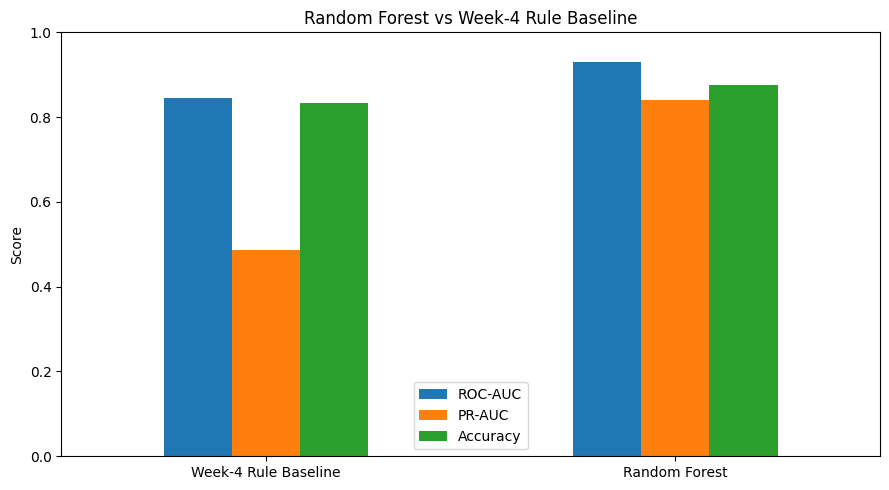

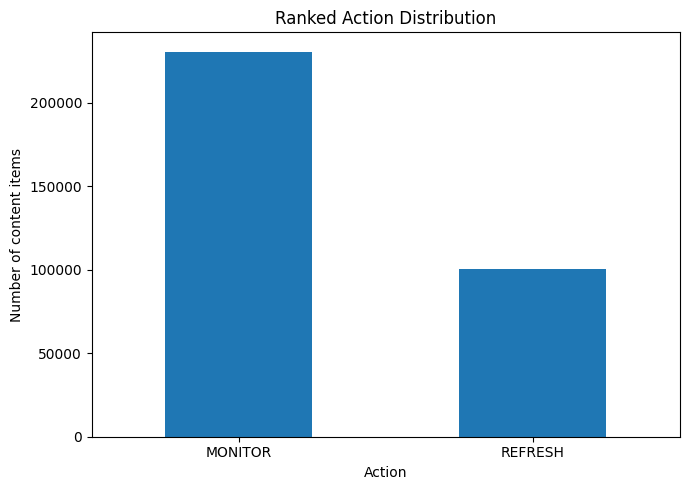

PAPER ARTIFACTS CREATED
Metrics figure: work/figures/model_vs_baseline.png
Action figure:  work/figures/action_distribution.png
Top-20 table:   work/outputs/top20_ranked_recommendations.csv

Top 10 recommendations:


,rank,client_hash_id,content_hash_id,score,reason_code,action
0,1,client_e547b89c05043229,content_eadb33b5df496f4a,13.210371,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
1,2,client_23a62021009f63c4,content_e8a52cf3d5988c07,12.374843,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
2,3,client_e547b89c05043229,content_ec2e0346994fb5a5,12.335260,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
3,4,client_e547b89c05043229,content_0e03de7680314cd5,12.267284,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
4,5,client_23a62021009f63c4,content_44f34c0a90047651,12.264864,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
5,6,client_e547b89c05043229,content_8d7d99f109e19aa2,12.206052,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
6,7,client_62f4a7e64f5e0096,content_7172a7fad43f0998,12.183760,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
7,8,client_23a62021009f63c4,content_36e53e9c707674fc,12.163452,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
8,9,client_62f4a7e64f5e0096,content_b99ea6861864dea5,12.154734,HIGH_IMPRESSIONS_LOW_CTR,REFRESH
9,10,client_62f4a7e64f5e0096,content_f107e54b10b43725,12.123935,HIGH_IMPRESSIONS_LOW_CTR,REFRESH


In [25]:

# SECTION 7 — PAPER ARTIFACTS

import os
import matplotlib.pyplot as plt

os.makedirs("work/figures", exist_ok=True)
os.makedirs("work/outputs", exist_ok=True)


# 1. MODEL VS BASELINE METRICS


metrics_plot = results.set_index("Method")[
    ["ROC-AUC", "PR-AUC", "Accuracy"]
]

ax = metrics_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Random Forest vs Week-4 Rule Baseline")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()

metrics_path = "work/figures/model_vs_baseline.png"
plt.savefig(metrics_path, dpi=150)
plt.show()


# 2. ACTION DISTRIBUTION


action_counts = (
    baseline_queue["action"]
    .value_counts()
)

plt.figure(figsize=(7, 5))
action_counts.plot(kind="bar")

plt.title("Ranked Action Distribution")
plt.xlabel("Action")
plt.ylabel("Number of content items")
plt.xticks(rotation=0)
plt.tight_layout()

action_path = "work/figures/action_distribution.png"
plt.savefig(action_path, dpi=150)
plt.show()


# 3. TOP 20 RECOMMENDATIONS TABLE


top20 = baseline_queue.head(20).copy()

top20_path = "work/outputs/top20_ranked_recommendations.csv"

top20.to_csv(
    top20_path,
    index=False
)


# VERIFICATION


print("=" * 70)
print("PAPER ARTIFACTS CREATED")
print("=" * 70)

print(f"Metrics figure: {metrics_path}")
print(f"Action figure:  {action_path}")
print(f"Top-20 table:   {top20_path}")

print()
print("Top 10 recommendations:")
display(top20.head(10))

## ML-12 — Communication outputs

### 5-minute demo outline

1. Research question and decision supported.
2. March feature window and April outcome definition.
3. Random Forest versus the Week-4 rule baseline.
4. Validation results and main error/limitation.
5. Ranked content-review queue and human-review workflow.

### Social-post cut

I built a content-opportunity scoring workflow using the FlyRank ML Internship dataset. A Random Forest achieved measured ROC-AUC of 0.9312 versus 0.8447 for the Week-4 rule baseline on the same validation data. The output is decision-support for human review, not an automated instruction to refresh content.

### Employer-facing summary

Built and evaluated a Random Forest content-opportunity model using observed Search Console and Analytics performance signals. The model measured higher validation ROC-AUC and PR-AUC than the Week-4 rule baseline on the same held-out data. I also built a ranked action queue with leakage checks, error analysis, human-review rules, and explicit limitations.

## Self-check

- [x] Every section above is filled with markdown explanations and supporting code.
- [x] The notebook has been run through the completed sections without errors.
- [x] No client names, private URLs, or private search queries are included in the analysis.
- [x] Claims use careful language such as observed, measured, directional, and decision-support.
- [x] Model and baseline results use the same validation data and metrics.
- [x] The target base rate is reported alongside the evaluation results.
- [x] The final feature set excludes client/content identifiers and future target information.
- [x] The ranked recommendation queue is reproduced from the Week-4 baseline logic.
- [x] Human review is required before any content action.
- [x] No publishing, deletion, redirection, metadata change, or other content change is automated.
- [x] Paper artifacts were generated under `work/figures/` and `work/outputs/`.
- [x] The deployed paper contains all required paper sections, including the Abstract and Acknowledgments & data credit.
- [x] The exact deployed paper URL has been written to `submission/paper_url.txt`.
- [x] The notebook and paper artifacts have been committed and pushed to the repository.
- [x] The final public-safety review has been completed.